# Brain Tumor Classification using CNN
**Problem:** Medical Image Classification  
**Dataset:** Brain Tumor MRI — [Kaggle](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)  
**Classes:** Glioma | Meningioma | No Tumor | Pituitary  
**Techniques:** Transfer Learning (ResNet-18), Dropout, Data Augmentation, MC Dropout Uncertainty

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Data Loading

In [2]:
zip_path = '/content/drive/MyDrive/Dataset/archive.zip'

In [3]:
import zipfile
from pathlib import Path

zip_path = '/content/drive/MyDrive/Dataset/archive.zip'
extract_path = '/content/data'

if not Path(extract_path + '/Training').exists():
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print("Dataset extracted successfully")
else:
    print("Dataset already exists")

Dataset extracted successfully


In [4]:
DATASET_PATH = '/content/data'

In [5]:
from google.colab import drive
from pathlib import Path
import zipfile

# ربط Google Drive
drive.mount('/content/drive')

# مسار ملف الـ zip على Drive
zip_path = '/content/drive/MyDrive/Dataset/archive.zip'

# المكان اللي هتفك فيه الداتا
extract_path = '/content/data'

# فك الضغط مرة واحدة فقط
if not Path(extract_path + '/Training').exists():
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print('Dataset ready.')
else:
    print('Data already loaded.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data already loaded.


In [6]:
import random, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image

SEED        = 42
IMG_SIZE    = 224
BATCH_SIZE  = 32
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
TRAIN_DIR   = Path('data/Training')
TEST_DIR    = Path('data/Testing')

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


## 2. Preprocessing

In [7]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
print('Transforms defined.')


Transforms defined.


In [8]:
class BrainTumorDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples   = [
            (p, i)
            for i, cls in enumerate(CLASS_NAMES)
            for p in sorted((Path(root)/cls).iterdir())
            if p.suffix.lower() in {'.jpg','.jpeg','.png'}
        ]
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p, lbl = self.samples[i]
        img = Image.open(p).convert('RGB')
        return (self.transform(img) if self.transform else img), lbl

full      = BrainTumorDataset(TRAIN_DIR, train_tf)
full_eval = BrainTumorDataset(TRAIN_DIR, eval_tf)
test_ds   = BrainTumorDataset(TEST_DIR,  eval_tf)

idx = list(range(len(full))); random.shuffle(idx)
v   = int(len(idx) * 0.2)
train_ds = Subset(full,      idx[v:])
val_ds   = Subset(full_eval, idx[:v])

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')


Train: 4480 | Val: 1120 | Test: 1600


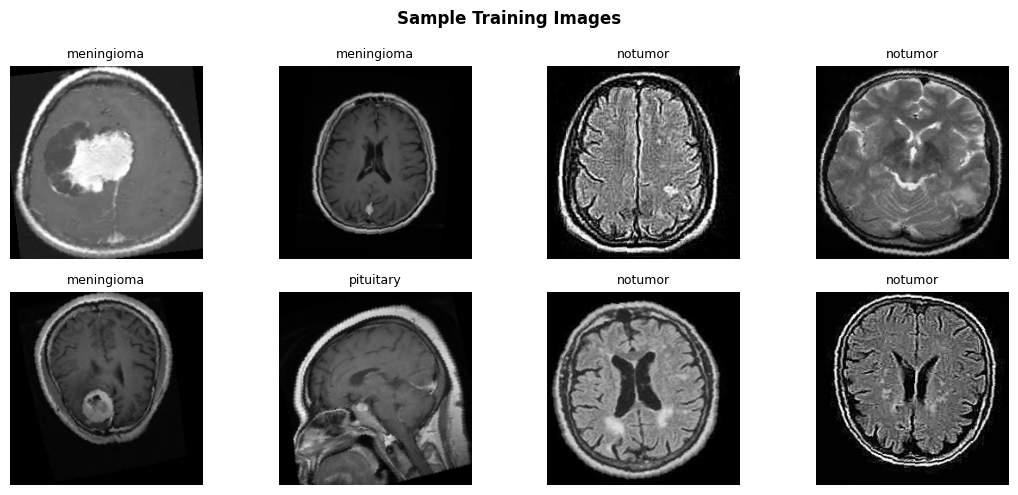

In [9]:
def denorm(t):
    m, s = torch.tensor(MEAN).view(3,1,1), torch.tensor(STD).view(3,1,1)
    return (t*s+m).clamp(0,1)

imgs, lbls = next(iter(train_loader))
fig, axes  = plt.subplots(2, 4, figsize=(11, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(denorm(imgs[i]).permute(1,2,0))
    ax.set_title(CLASS_NAMES[lbls[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontweight='bold')
plt.tight_layout(); plt.show()


## 3. Model Architecture
- **Base:** ResNet-18 pretrained on ImageNet (backbone frozen)
- **Head:** Dropout → Linear(512→256) → ReLU → Dropout → Linear(256→4)
- **Enhancement:** Dropout regularization + Data Augmentation

In [10]:
class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4, dropout=0.5):
        super().__init__()
        backbone = models.resnet18(weights='DEFAULT')
        for p in backbone.parameters(): p.requires_grad = False
        self.features   = nn.Sequential(*list(backbone.children())[:-1])
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x).view(x.size(0), -1))

model     = BrainTumorCNN(num_classes=4, dropout=0.5).to(device)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}  ({100*trainable/total:.1f}%)')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 103MB/s] 

Total params    : 11,308,868
Trainable params: 132,356  (1.2%)


## 4. Training

In [11]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

def run_epoch(model, loader, optimizer=None, train=True):
    model.train() if train else model.eval()
    loss_sum, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            loss_sum += loss.item() * imgs.size(0)
            correct  += (out.argmax(1) == lbls).sum().item()
            total    += imgs.size(0)
    return loss_sum / total, 100 * correct / total

In [12]:
EPOCHS    = 15
best_loss = float('inf')
history   = {'tl': [], 'vl': [], 'ta': [], 'va': []}

print(f"{'Ep':>3}  {'Train Loss':>10}  {'Train Acc':>10}  {'Val Loss':>9}  {'Val Acc':>8}")
print('-' * 50)
for ep in range(1, EPOCHS + 1):
    tl, ta = run_epoch(model, train_loader, optimizer, train=True)
    vl, va = run_epoch(model, val_loader,   train=False)
    scheduler.step(vl)
    if vl < best_loss:
        best_loss = vl
        torch.save(model.state_dict(), 'best_model.pth')
        tag = ' *'
    else:
        tag = ''
    for k, v in zip(['tl','vl','ta','va'], [tl,vl,ta,va]): history[k].append(v)
    print(f'{ep:>3}  {tl:>10.4f}  {ta:>9.2f}%  {vl:>9.4f}  {va:>7.2f}%{tag}')


 Ep  Train Loss   Train Acc   Val Loss   Val Acc
--------------------------------------------------
  1      0.8434      65.38%     0.4955    80.54% *
  2      0.6373      75.18%     0.4111    84.46% *
  3      0.6154      75.33%     0.4429    84.91%
  4      0.5901      76.21%     0.3953    84.29% *
  5      0.5775      77.25%     0.4146    84.38%
  6      0.5903      77.12%     0.3940    85.62% *
  7      0.5840      76.61%     0.3785    87.32% *
  8      0.5690      77.90%     0.3520    86.70% *
  9      0.5597      78.10%     0.3751    85.80%
 10      0.5373      79.40%     0.3680    87.05%
 11      0.5375      78.44%     0.3524    86.43%
 12      0.5322      78.73%     0.3487    87.77% *
 13      0.5241      79.40%     0.3914    85.18%
 14      0.5437      78.97%     0.3673    86.25%
 15      0.5170      80.71%     0.3752    86.07%


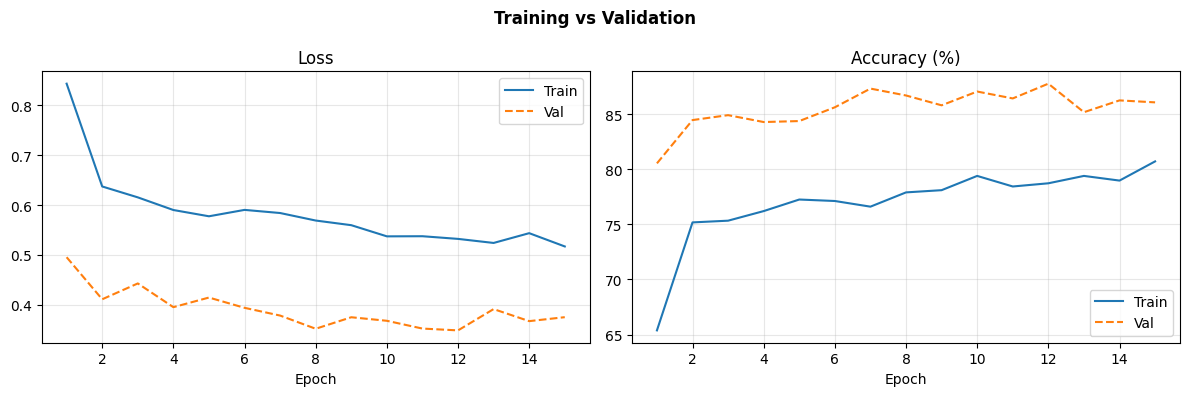

In [13]:
ep = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ep, history['tl'], label='Train'); ax1.plot(ep, history['vl'], label='Val', ls='--')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, history['ta'], label='Train'); ax2.plot(ep, history['va'], label='Val', ls='--')
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle('Training vs Validation', fontweight='bold')
plt.tight_layout(); plt.savefig('training_curves.png', dpi=150); plt.show()


## 5. Evaluation on Test Set

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load('best_model.pth', map_location=device))
test_loss, test_acc = run_epoch(model, test_loader, train=False)

preds_all, labels_all = [], []
model.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        preds_all.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
        labels_all.extend(lbls.numpy())

preds_all  = np.array(preds_all)
labels_all = np.array(labels_all)

print(f'Test Accuracy : {test_acc:.2f}%')
print(f'Test Loss     : {test_loss:.4f}\n')
print(classification_report(labels_all, preds_all, target_names=CLASS_NAMES))


Test Accuracy : 81.50%
Test Loss     : 0.5059

              precision    recall  f1-score   support

      glioma       0.86      0.65      0.74       400
  meningioma       0.71      0.68      0.69       400
     notumor       0.85      0.98      0.91       400
   pituitary       0.84      0.95      0.89       400

    accuracy                           0.81      1600
   macro avg       0.81      0.82      0.81      1600
weighted avg       0.81      0.81      0.81      1600



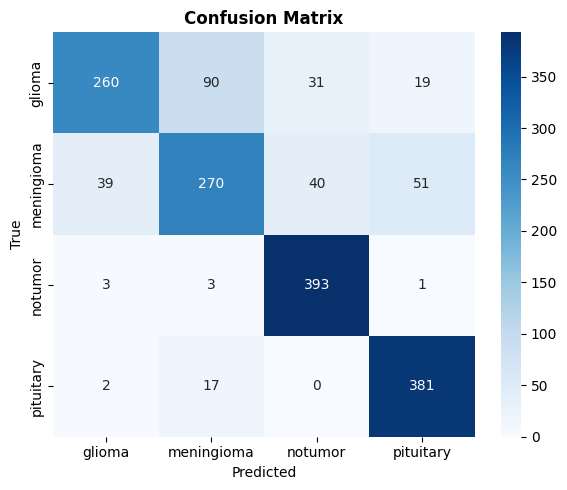

In [15]:
cm = confusion_matrix(labels_all, preds_all)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150); plt.show()


## 6. Uncertainty Estimation — MC Dropout *(Bonus)*
The model runs **30 times** on the same image with Dropout kept ON.  
Each pass drops different neurons → slightly different predictions.  
- **Low std** = model is confident  
- **High std** = model is uncertain

In [16]:
import torch.nn.functional as F

def mc_predict(model, imgs, n=30):
    model.eval()
    for m in model.modules():                  # keep Dropout ON during inference
        if isinstance(m, nn.Dropout): m.train()
    imgs = imgs.to(device)
    with torch.no_grad():
        probs = torch.stack([F.softmax(model(imgs), 1) for _ in range(n)])
    mean = probs.mean(0)
    return mean.cpu(), mean.argmax(1).cpu(), probs.std(0).mean(1).cpu()

# Run on full test set
all_pred, all_unc, all_lbl = [], [], []
for imgs, lbls in test_loader:
    _, pred, unc = mc_predict(model, imgs)
    all_pred.extend(pred.numpy())
    all_unc.extend(unc.numpy())
    all_lbl.extend(lbls.numpy())

all_pred = np.array(all_pred)
all_unc  = np.array(all_unc)
all_lbl  = np.array(all_lbl)

mc_acc = 100 * (all_pred == all_lbl).mean()
print(f'MC Test Accuracy : {mc_acc:.2f}%')
print(f'Mean Uncertainty : {all_unc.mean():.4f}')


MC Test Accuracy : 80.38%
Mean Uncertainty : 0.1137


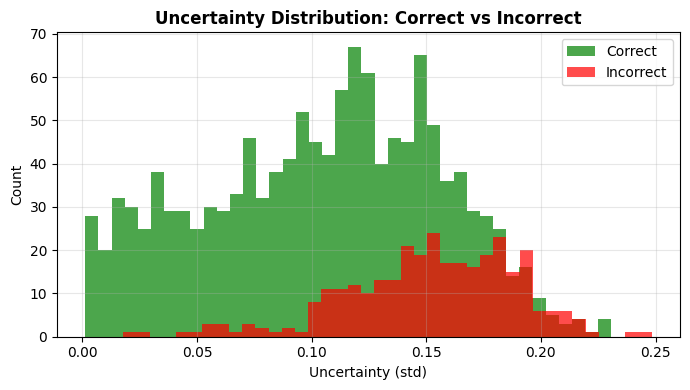

In [17]:
# Uncertainty: correct vs incorrect predictions
correct = (all_pred == all_lbl)
plt.figure(figsize=(7, 4))
plt.hist(all_unc[correct],  bins=40, alpha=0.7, label='Correct',   color='green')
plt.hist(all_unc[~correct], bins=40, alpha=0.7, label='Incorrect', color='red')
plt.xlabel('Uncertainty (std)'); plt.ylabel('Count')
plt.title('Uncertainty Distribution: Correct vs Incorrect', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('uncertainty.png', dpi=150); plt.show()


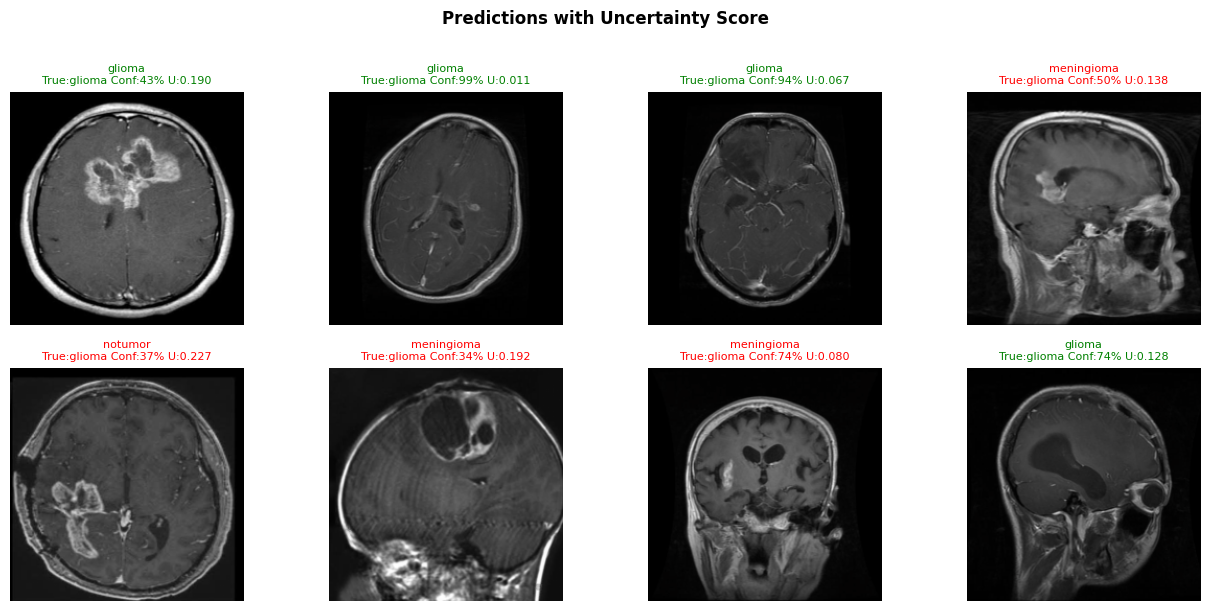

In [18]:
# Sample predictions with uncertainty score
t_imgs, t_lbls       = next(iter(test_loader))
mean_p, pred_c, unc  = mc_predict(model, t_imgs[:8])

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
fig.suptitle('Predictions with Uncertainty Score', fontweight='bold', y=1.01)
for i, ax in enumerate(axes.flat):
    ax.imshow(denorm(t_imgs[i]).permute(1,2,0))
    pred_cls = CLASS_NAMES[pred_c[i].item()]
    true_cls = CLASS_NAMES[t_lbls[i].item()]
    ok       = pred_c[i].item() == t_lbls[i].item()
    conf     = mean_p[i][pred_c[i]].item() * 100
    color    = 'green' if ok else 'red'
    ax.set_title(f'{pred_cls}\nTrue:{true_cls} Conf:{conf:.0f}% U:{unc[i]:.3f}',
                 color=color, fontsize=8)
    ax.axis('off')
    for sp in ax.spines.values(): sp.set_edgecolor(color); sp.set_linewidth(2.5)
plt.tight_layout(); plt.savefig('predictions_uncertainty.png', dpi=150); plt.show()


## 7. Experimentation

| Model | Optimizer | Learning Rate | Dropout |
|-------|-----------|---------------|---------|
| Exp 1 — Baseline | Adam | 1e-3 | 0.5 |
| Exp 2 — Low LR   | Adam | 1e-4 | 0.5 |
| Exp 3 — SGD      | SGD  | 1e-3 | 0.3 |

In [19]:
import copy

def run_experiment(name, opt_name='adam', lr=1e-3, dropout=0.5, epochs=10):
    print(f'\n--- {name} ---')
    m    = BrainTumorCNN(num_classes=4, dropout=dropout).to(device)
    prms = filter(lambda p: p.requires_grad, m.parameters())
    opt  = optim.Adam(prms, lr=lr) if opt_name == 'adam' else optim.SGD(prms, lr=lr, momentum=0.9)
    sch  = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    best_loss, best_w, hist = float('inf'), None, {'vl': [], 'va': []}

    print(f"{'Ep':>3}  {'Train Loss':>10}  {'Train Acc':>10}  {'Val Loss':>9}  {'Val Acc':>8}")
    print('-' * 50)
    for ep in range(1, epochs + 1):
        tl, ta = run_epoch(m, train_loader, opt,  train=True)
        vl, va = run_epoch(m, val_loader,         train=False)
        sch.step(vl)
        if vl < best_loss: best_loss = vl; best_w = copy.deepcopy(m.state_dict())
        hist['vl'].append(vl); hist['va'].append(va)
        print(f'{ep:>3}  {tl:>10.4f}  {ta:>9.2f}%  {vl:>9.4f}  {va:>7.2f}%')

    m.load_state_dict(best_w)
    t_loss, t_acc = run_epoch(m, test_loader, train=False)
    print(f'\n  => Test Accuracy: {t_acc:.2f}%  |  Test Loss: {t_loss:.4f}')
    return hist, t_acc, t_loss

print('Ready.')

Ready.


In [20]:
EXP_EPOCHS = 10
h1, a1, l1 = run_experiment('Exp 1 — Baseline (Adam, lr=1e-3)', 'adam', 1e-3, 0.5, EXP_EPOCHS)
h2, a2, l2 = run_experiment('Exp 2 — Low LR  (Adam, lr=1e-4)', 'adam', 1e-4, 0.5, EXP_EPOCHS)
h3, a3, l3 = run_experiment('Exp 3 — SGD     (SGD,  lr=1e-3)', 'sgd',  1e-3, 0.3, EXP_EPOCHS)



--- Exp 1 — Baseline (Adam, lr=1e-3) ---
 Ep  Train Loss   Train Acc   Val Loss   Val Acc
--------------------------------------------------
  1      0.8373      65.27%     0.4536    83.93%
  2      0.6254      75.45%     0.4467    83.12%
  3      0.6202      75.47%     0.4227    83.12%
  4      0.5992      76.63%     0.4078    85.18%
  5      0.5745      77.88%     0.3889    85.89%
  6      0.5822      77.21%     0.4177    84.91%
  7      0.5723      77.63%     0.3930    85.36%
  8      0.5450      78.21%     0.4318    82.50%
  9      0.5594      78.62%     0.3785    86.34%
 10      0.5598      77.46%     0.3854    86.52%

  => Test Accuracy: 78.69%  |  Test Loss: 0.5759

--- Exp 2 — Low LR  (Adam, lr=1e-4) ---
 Ep  Train Loss   Train Acc   Val Loss   Val Acc
--------------------------------------------------
  1      1.2572      43.08%     0.9631    78.12%
  2      0.9429      63.12%     0.6753    82.59%
  3      0.7917      69.53%     0.5628    83.66%
  4      0.7115      72.30%   

In [21]:
# Results comparison table
results  = [
    ('Exp 1 — Baseline', 'Adam', '1e-3', '0.5', a1, l1),
    ('Exp 2 — Low LR',   'Adam', '1e-4', '0.5', a2, l2),
    ('Exp 3 — SGD',      'SGD',  '1e-3', '0.3', a3, l3),
]
best_acc = max(r[4] for r in results)

print(f"\n{'Model':<25} {'Optimizer':>9} {'LR':>6} {'Dropout':>8} {'Accuracy':>10} {'Loss':>8}")
print('=' * 72)
for name, opt, lr, dr, acc, loss in results:
    marker = ' <<' if acc == best_acc else ''
    print(f'{name:<25} {opt:>9} {lr:>6} {dr:>8} {acc:>9.2f}%{marker:<4} {loss:>8.4f}')
print('=' * 72)
print('<< Best model')



Model                     Optimizer     LR  Dropout   Accuracy     Loss
Exp 1 — Baseline               Adam   1e-3      0.5     78.69%       0.5759
Exp 2 — Low LR                 Adam   1e-4      0.5     78.75%       0.5847
Exp 3 — SGD                     SGD   1e-3      0.3     79.62% <<    0.5605
<< Best model


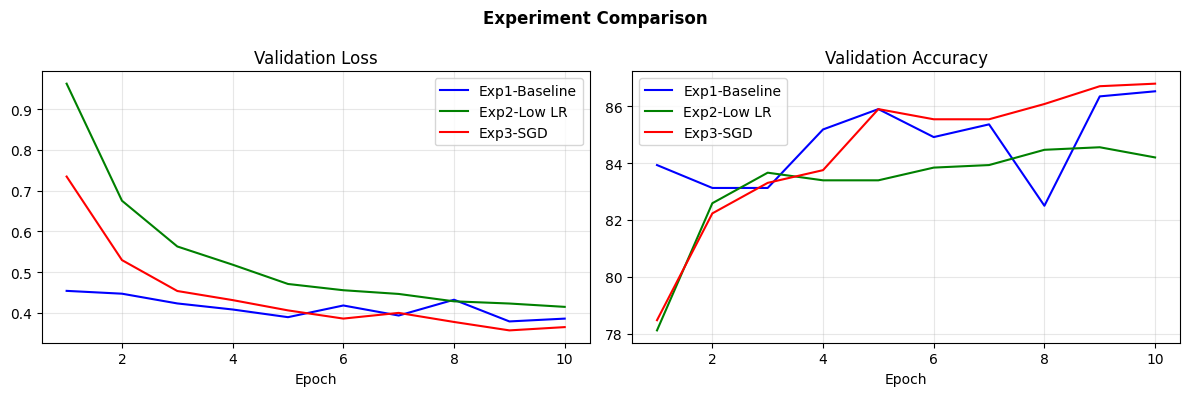

In [22]:
ep = range(1, EXP_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for name, hist, col in [('Exp1-Baseline',h1,'blue'),('Exp2-Low LR',h2,'green'),('Exp3-SGD',h3,'red')]:
    ax1.plot(ep, hist['vl'], label=name, color=col)
    ax2.plot(ep, hist['va'], label=name, color=col)
ax1.set_title('Validation Loss');     ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.set_title('Validation Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle('Experiment Comparison', fontweight='bold')
plt.tight_layout(); plt.savefig('experiment_comparison.png', dpi=150); plt.show()


## 8. Final Results Summary

In [23]:
from sklearn.metrics import f1_score
f1     = f1_score(labels_all, preds_all, average='weighted')
winner = results[[r[4] for r in results].index(best_acc)][0]

print('=' * 52)
print('           FINAL RESULTS SUMMARY')
print('=' * 52)
print(f'  Baseline Test Accuracy  : {test_acc:.2f}%')
print(f'  Baseline Test Loss      : {test_loss:.4f}')
print(f'  F1 Score (weighted)     : {f1:.4f}')
print(f'  MC Uncertainty (mean)   : {all_unc.mean():.4f}')
print('-' * 52)
print(f'  Exp 1 (Adam lr=1e-3)    : {a1:.2f}%  loss={l1:.4f}')
print(f'  Exp 2 (Adam lr=1e-4)    : {a2:.2f}%  loss={l2:.4f}')
print(f'  Exp 3 (SGD  lr=1e-3)    : {a3:.2f}%  loss={l3:.4f}')
print(f'  Best Experiment         : {winner}')
print('=' * 52)
print('\nAnalysis:')
print('  Exp 1: Adam lr=1e-3 converges fast — strong baseline.')
print('  Exp 2: Lower lr slows convergence, may need more epochs.')
print('  Exp 3: SGD + lower dropout gives more model capacity.')
print('\nDone!')


           FINAL RESULTS SUMMARY
  Baseline Test Accuracy  : 81.50%
  Baseline Test Loss      : 0.5059
  F1 Score (weighted)     : 0.8088
  MC Uncertainty (mean)   : 0.1137
----------------------------------------------------
  Exp 1 (Adam lr=1e-3)    : 78.69%  loss=0.5759
  Exp 2 (Adam lr=1e-4)    : 78.75%  loss=0.5847
  Exp 3 (SGD  lr=1e-3)    : 79.62%  loss=0.5605
  Best Experiment         : Exp 3 — SGD

Analysis:
  Exp 1: Adam lr=1e-3 converges fast — strong baseline.
  Exp 2: Lower lr slows convergence, may need more epochs.
  Exp 3: SGD + lower dropout gives more model capacity.

Done!


In [24]:
# UPGRADED CNN → CriticNet DATA PIPELINE


import torch
import numpy as np
import pandas as pd

from tqdm import tqdm
from torch.utils.data import ConcatDataset, DataLoader

# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

# ============================================================
# 2. COMBINE ALL DATASETS
# ============================================================

combined_dataset = ConcatDataset([
    train_loader.dataset,
    val_loader.dataset,
    test_loader.dataset
])

combined_loader = DataLoader(
    combined_dataset,
    batch_size=32,
    shuffle=False
)

print("✅ Total samples in Critic Dataset:",
      len(combined_dataset))

# 3. CLASS NAMES


class_names = [
    'glioma',
    'meningioma',
    'notumor',
    'pituitary'
]

# ============================================================
# 4. SOFTMAX
# ============================================================

softmax = torch.nn.Softmax(dim=1)

# ============================================================
# 5. MONTE CARLO DROPOUT FUNCTION
# ============================================================

def mc_dropout_predict(model, x, n_iter=30):

    """
    Keeps Dropout ON during inference.

    Multiple forward passes are performed
    to estimate uncertainty.
    """

    model.train()

    predictions = []

    with torch.no_grad():

        for _ in range(n_iter):

            outputs = model(x)

            probs = softmax(outputs)

            predictions.append(
                probs.cpu().numpy()
            )

    predictions = np.array(predictions)

    # Mean probabilities
    mean_probs = predictions.mean(axis=0)

    # Variance between predictions
    var_probs = predictions.var(axis=0)

    return mean_probs, var_probs

# ============================================================
# 6. GENERATE DATASET
# ============================================================

results = []

print("\nGenerating CriticNet dataset...\n")

for i, (images, labels) in enumerate(
    tqdm(combined_loader)
):

    images = images.to(device)

    # -----------------------------------
    # MC Dropout Predictions
    # -----------------------------------

    mean_probs, var_probs = mc_dropout_predict(
        model,
        images,
        n_iter=30
    )

    # -----------------------------------
    # Process Each Image
    # -----------------------------------

    for j in range(images.size(0)):

        probs = mean_probs[j]

        variance = var_probs[j]

        # -----------------------------------
        # Prediction Info
        # -----------------------------------

        predicted_class = np.argmax(probs)

        true_class = labels[j].item()

        confidence = float(np.max(probs))

        correct = int(
            predicted_class == true_class
        )

        # ====================================================
        # ADVANCED UNCERTAINTY FEATURES
        # ====================================================

        # Mean variance
        uncertainty = float(
            np.mean(variance)
        )

        # Max variance
        max_variance = float(
            np.max(variance)
        )

        # Entropy
        entropy = float(
            -np.sum(
                probs * np.log(probs + 1e-10)
            )
        )

        # Margin between top two probs
        sorted_probs = np.sort(probs)[::-1]

✅ Total samples in Critic Dataset: 7200

Generating CriticNet dataset...



100%|██████████| 225/225 [04:18<00:00,  1.15s/it]


In [26]:
critic_df = pd.DataFrame(results)

critic_df.to_csv(
    '/content/drive/MyDrive/critic_dataset.csv',
    index=False
)

print(" Critic Dataset Saved Successfully")

 Critic Dataset Saved Successfully


In [27]:
import os
print(os.path.exists('/content/drive/MyDrive/critic_dataset.csv'))
print(os.path.exists('/content/critic_dataset.csv'))

True
False


In [28]:
!ls /content/drive/MyDrive/

 17719437012935207178243347482711.jpg   Dataset
'20250818_001702 (1).jpg'	        dl
 20250818_001702.jpg		        IMG-20250430-WA0400.jpg
 20250918_204155.jpg		        IMG-20250821-WA0069.jpg
'20250918_204212 (1).jpg'	        IMG-20251104-WA0042.jpg
'20250918_204212 (2).jpg'	        IMG-20260310-WA0039.jpg
 20250918_204212.jpg		        inbound1392337698575634577.jpg
'20250918_204710 (1).jpg'	        inbound2816583344402746931.pdf
 20250918_204710.jpg		        inbound6168844843926614646.pdf
 20251125_221250.jpg		        inbound6920770107978276557.pdf
'20251125_221315 (1).jpg'	       'Plans '
 20251125_221315.jpg		       'Radwa_CV (1).pdf'
 20251125_221455.jpg		        Radwa_CV.pdf
'Colab Notebooks'		       'نموذج بدون عنوان (File responses)'
 critic_dataset.csv
